# L13c Example: NanoGPT on Tiny Shakespeare
This example trains a small character-level decoder-only language model on the Tiny Shakespeare corpus and samples from it. The point is not to produce readable text. It is to make every moving part of the L13c lecture concrete and observable: a real causal-attention layer, a real next-token-prediction training loop, and real autoregressive sampling with greedy, temperature, and top-$k$ decoding.

> __Problem statement.__ We have a single text file (the complete works of Shakespeare concatenated into about $1.1$ million characters). We train a small language model on this file by next-token prediction, then use it to generate new text starting from a prompt.

The generated text will look like Shakespeare-shaped gibberish, and that is by design. Three points frame what to expect:

* __What the model cannot learn:__ At this scale the model has too few parameters and sees too few gradient updates to learn real spelling, grammar, or meaning. No individual generated word will be a real English word.
* __What the model does learn:__ From a character-level corpus in a short run, the model captures surface statistics such as where line breaks occur, that lines often begin with an uppercase name followed by a colon, that words are roughly four to six characters long, and that certain letter pairs ($th$, $ou$, $er$) are common while others ($qz$, $fj$) never appear.
* __Why that is the signal we want:__ Seeing the surface statistics reproduced in the output, even without real words, is the direct evidence that next-token training transferred the corpus statistics into the model weights.

That structural signature is what we will confirm in the sampling step.

The rest of this notebook works toward that goal in three tasks: preparing the corpus, building and training the model, and sampling from it.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Build and train a decoder-only language model from scratch:__ Assemble a small transformer language model from causal attention and decoder-block components, and train it on a character-level corpus with next-token prediction cross-entropy loss.
> * __Generate text with three sampling strategies:__ Use greedy decoding, temperature sampling, and top-$k$ sampling on the trained model and explain by inspection how each strategy trades off determinism against diversity.
> * __Read a causal attention pattern:__ Plot the attention weights of one of the trained heads on a real input sequence and identify the lower-triangular structure imposed by the causal mask.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and includes local source files in `src/`. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

In [1]:
include("Include.jl"); # load the packages, source files and set the random seed for reproducibility

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c`


### Constants

In [2]:
CORPUS_PREVIEW_N_CHARS = 200
ROUNDTRIP_TEST_STRING = "First Citizen:"
TRAIN_SPLIT_FRACTION = 0.9

MODEL_SEED = 42
D_MODEL = 64
N_HEADS = 4
N_LAYERS = 2
CTX_LEN = 128
D_FF = 4 * D_MODEL
BATCHSIZE = 32
CHECKPOINT_PATH = joinpath(_PATH_TO_DATA, "nanogpt_d$(D_MODEL)_h$(N_HEADS)_l$(N_LAYERS)_c$(CTX_LEN).jld2")
N_EPOCHS = 20
N_ITERS_PER_EPOCH = 500
LR = 3.0f-3

SAMPLE_PROMPT = "ROMEO:"
GENERATION_LENGTH = 250
GREEDY_TEMPERATURE = 0
SAMPLING_TEMPERATURE = 0.8
TOP_K = 10
SAMPLING_RNG_SEED = 7

ATTN_RNG_SEED = 2026
ATTN_SAMPLE_BATCHSIZE = 1
ATTN_SAMPLE_INDEX = 1
ATTN_BLOCK_INDEX = 1
ATTN_HEAD_INDEX = 1

1

___

## Task 1: Prepare the Tiny Shakespeare corpus
The first task is to turn the raw text file into integer tensors the model can consume.

> __Corpus preparation.__ We (i) download the corpus from the char-rnn GitHub repo (cached locally after the first run), (ii) build a character-level vocabulary that maps each unique character to an integer id, (iii) encode the full corpus as an integer vector, and (iv) hold out the last 10% as a validation set so we can monitor for overfitting.

The code block below returns the vocabulary as `vocab::Vocabulary`, the integer-encoded training portion of the corpus as `TRAIN_DATA::Vector{Int}`, and the integer-encoded validation portion as `VAL_DATA::Vector{Int}`.

In [3]:
vocab, TRAIN_DATA, VAL_DATA = let

    # (i) load corpus from cache or download
    path = download_shakespeare(_PATH_TO_DATA);
    text = read(path, String);
    @info "corpus loaded" path n_chars=length(text)
    println();
    println("First $(CORPUS_PREVIEW_N_CHARS) characters of the corpus:");
    println("---");
    println(text[1:CORPUS_PREVIEW_N_CHARS]);
    println("---");

    # (ii) build character-level vocabulary
    vocab = build_vocab(text);
    @info "vocabulary built" vocab_size=vocab.vocab_size
    println("Vocab characters: \"", join(sort(collect(keys(vocab.char_to_id))), ""), "\"")

    # encode/decode roundtrip sanity check
    test_str = ROUNDTRIP_TEST_STRING;
    ids = encode(test_str, vocab);
    println("encoded \"", test_str, "\" -> ", ids);
    println("decoded back: \"", decode(ids, vocab), "\"");

    # (iii) encode full corpus and (iv) 90/10 split
    data = encode(text, vocab);
    n_train = round(Int, TRAIN_SPLIT_FRACTION * length(data));
    TRAIN_DATA = data[1:n_train];
    VAL_DATA   = data[n_train+1:end];
    @info "train/val split" n_train=length(TRAIN_DATA) n_val=length(VAL_DATA)

    # return -
    (vocab, TRAIN_DATA, VAL_DATA)
end;

┌ Info: corpus loaded
│   path = /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/data/input.txt
│   n_chars = 1115394
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y445sZmlsZQ==.jl:6



First 200 characters of the corpus:
---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you
---


┌ Info: vocabulary built
│   vocab_size = 65
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y445sZmlsZQ==.jl:15


Vocab characters: "
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
encoded "First Citizen:" -> [19, 48, 57, 58, 59, 2, 16, 48, 59, 48, 65, 44, 53, 11]
decoded back: "First Citizen:"


┌ Info: train/val split
│   n_train = 1003855
│   n_val = 111539
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y445sZmlsZQ==.jl:29


With the corpus encoded and split into training and validation partitions, we can now build the model that will be trained on them.

___

## Task 2: Build and train the NanoGPT model
The second task is to assemble a decoder-only language model and train it on the corpus prepared in Task 1.

> __Model and training setup.__ The model has two transformer blocks ($L = 2$), four attention heads ($H = 4$), model dimension $d = 64$, and a context length of $n_{\max} = 128$ characters. For a vocabulary of size $V$, the expected parameter count is $2 V d + n_{\max} d + L\,(12 d^{2} + 9 d) + 2 d$. We train with Adam at learning rate $3\times 10^{-3}$ for $20$ epochs of $500$ iterations each (that is $10{,}000$ gradient steps), sampling random `(input, target)` chunks from the training corpus on each iteration. The first run trains from scratch and saves a checkpoint under `data/`; subsequent runs detect the checkpoint and load it instead of retraining.

The code block below returns the trained model as `model::NanoGPT`, the vector of per-epoch mean training losses as `train_history::Vector{Float32}`, and the vector of per-epoch validation losses as `val_history::Vector{Float32}`.

In [4]:
model, train_history, val_history = let

    VOCAB = vocab.vocab_size;

    # build the model
    Random.seed!(MODEL_SEED);
    model = NanoGPT(VOCAB, D_MODEL, N_HEADS, N_LAYERS, CTX_LEN; d_ff = D_FF);
    @info "NanoGPT model built" n_params=n_parameters(model) vocab=VOCAB d_model=D_MODEL n_heads=N_HEADS n_layers=N_LAYERS ctx_len=CTX_LEN

    train_history = Float32[];
    val_history   = Float32[];

    # load checkpoint if it exists, otherwise train from scratch
    if isfile(CHECKPOINT_PATH)
        @info "Loading pre-trained checkpoint" path=CHECKPOINT_PATH
        saved = JLD2.load(CHECKPOINT_PATH);
        Flux.loadmodel!(model, saved["model_state"]);
        train_history = saved["train_history"];
        val_history   = saved["val_history"];
        @info "Loaded model from checkpoint"
    else
        @info "No checkpoint found, training from scratch..."
        Random.seed!(MODEL_SEED);
        opt = Flux.setup(Adam(LR), model);
        for epoch in 1:N_EPOCHS
            epoch_losses = Float32[];
            for it in 1:N_ITERS_PER_EPOCH
                Xb, Yb = sample_batch(TRAIN_DATA, BATCHSIZE, CTX_LEN);
                l, gs = Flux.withgradient(model) do m
                    nanogpt_loss(m, Xb, Yb)
                end
                push!(epoch_losses, l);
                Flux.update!(opt, model, gs[1]);
            end
            train_l = mean(epoch_losses);
            push!(train_history, train_l);
            Xv, Yv = sample_batch(VAL_DATA, BATCHSIZE, CTX_LEN);
            val_l = nanogpt_loss(model, Xv, Yv);
            push!(val_history, val_l);
            @info "epoch" epoch train_loss=round(train_l, digits=4) val_loss=round(val_l, digits=4)
        end
        JLD2.jldsave(CHECKPOINT_PATH;
                      model_state = Flux.state(model),
                      train_history = train_history,
                      val_history = val_history);
        @info "Saved checkpoint" path=CHECKPOINT_PATH
    end

    # return -
    (model, train_history, val_history)
end;

┌ Info: NanoGPT model built
│   n_params = 116096
│   vocab = 65
│   d_model = 64
│   n_heads = 4
│   n_layers = 2
│   ctx_len = 128
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y451sZmlsZQ==.jl:8
┌ Info: No checkpoint found, training from scratch...
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y451sZmlsZQ==.jl:22
┌ Info: epoch
│   epoch = 1
│   train_loss = 2.3969
│   val_loss = 2.0468
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y451sZmlsZQ==.jl:40
┌ Info: epoch
│   epoch = 2
│   train_loss = 1.7996
│   val_loss = 1.8602
└ @ Main /Users/jeffreyvarner/Desktop/julia_work

### Training loss curve
> __Sanity check.__ Before moving on, we plot the per-epoch training and validation losses. Both should decrease steadily and stay close together, which means the model is learning the corpus without overfitting.

The cell below plots both curves on a single axis.

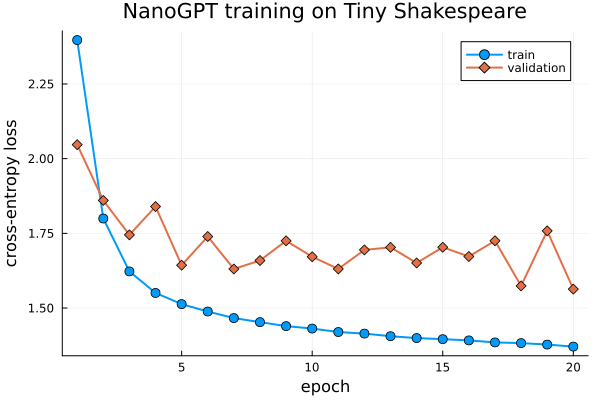

In [5]:
let
    plot(1:length(train_history), train_history;
         xlabel = "epoch", ylabel = "cross-entropy loss",
         label = "train",
         title = "NanoGPT training on Tiny Shakespeare",
         linewidth = 2, marker = :circle, markersize = 5,
         legend = :topright);
    plot!(1:length(val_history), val_history;
          label = "validation",
          linewidth = 2, marker = :diamond, markersize = 5)
end

## Task 3: Sample from the model and visualize causal attention
With a trained model in hand, we generate text with three decoding strategies and then inspect one head's attention weights:

* __Shared conditions:__ All three sampling strategies use the same prompt, `"ROMEO:"`, and the same generation length, $250$ characters, so any differences in output come from the decoding rule, not the prompt.
* __How to read the output:__ Do not read the generated text for meaning, read it for structure. In every sample you should see line breaks, an uppercase speaker name followed by a colon at the start of each line, and tokens that resemble English words in length and letter frequency even when they are not real words.
* __Diagnostic contrast between decoders:__ Greedy decoding is deterministic and typically gets stuck repeating a short phrase, temperature sampling breaks the loop but occasionally emits improbable characters, and top-$k$ sampling breaks the loop while filtering out the worst of those improbable tokens.

The attention heatmap then confirms the causal-mask pattern from the lecture on a real input sequence.

### Decoding strategies
> __Three decoding rules.__ Greedy decoding picks the highest-logit token at every step; it is deterministic and equivalent to the $\tau \to 0$ limit of temperature sampling. Temperature sampling scales the logits by $1/\tau$ before softmax; with $\tau = 0.8$ the distribution stays sharp but is no longer deterministic. Top-$k$ sampling is temperature sampling restricted to the $k$ highest-logit tokens at every step.

The code block below runs all three decoders on the same prompt and prints the generated text for comparison. Compare the three outputs: greedy should quickly enter a repeating pattern, while temperature and top-$k$ continue to produce fresh (if nonsensical) text.

In [6]:
println("--- greedy (τ → 0) ---")
println(sample_text(model, vocab, SAMPLE_PROMPT, GENERATION_LENGTH; temperature = GREEDY_TEMPERATURE))
println()

println("--- temperature (τ = $(SAMPLING_TEMPERATURE)) ---")
println(sample_text(model, vocab, SAMPLE_PROMPT, GENERATION_LENGTH; temperature = SAMPLING_TEMPERATURE, rng = MersenneTwister(SAMPLING_RNG_SEED)))
println()

println("--- top-k (τ = $(SAMPLING_TEMPERATURE), k = $(TOP_K)) ---")
println(sample_text(model, vocab, SAMPLE_PROMPT, GENERATION_LENGTH; temperature = SAMPLING_TEMPERATURE, top_k = TOP_K, rng = MersenneTwister(SAMPLING_RNG_SEED)))

--- greedy (τ → 0) ---
ROMEO:
The sensile of the state of the state of the state
That thou art the state the stread of the face
That the fire of the fire of the fire
That the fire of the fire of the fire
That the fire of the fire of the fire
That the fire of the fire of the fire

--- temperature (τ = 0.8) ---
ROMEO:
What! let's keep and my father's mall,
As from you rest. How she marriage on my heart,
Be done, come time in not welcome come,
From you bear reember the these arm and to dire.

Provost:
I will seem you most far them for your humour.
O, now I foot hi

--- top-k (τ = 0.8, k = 10) ---
ROMEO:
What! morrow me have my father's name,
As how as a partly to the man affright he hardle
I'll profer forswear of time to me a morn.

STANLEY:
Nor be it soul with that your highness, and whiten,
That we are the rest the power; by my now.

KING HENRY V


### Causal attention heatmap
> __Attention extraction.__ Each attention head in the model produces a $T\times T$ matrix of attention weights at each forward pass, where $T$ is the context length and $H$ is the number of heads. Because of the causal mask, every row $i$ has zero weight at all columns $j > i$, so the matrix is strictly lower-triangular. We pick a random input sequence from the validation set, run the embeddings and the first decoder block's pre-norm on it, and call `causal_attention_weights` to recover the $(T, T, H, 1)$ attention tensor from the first decoder block.

The code block below returns the attention-weight tensor of shape $(T, T, H, 1) = (128, 128, 4, 1)$ as `attn_w::Array{Float32, 4}` and the decoded character string of the input sequence as `input_chars::String`.

In [7]:
attn_w, input_chars = let

    # pick a sample input from the validation set
    Random.seed!(ATTN_RNG_SEED);
    Xb, _ = sample_batch(VAL_DATA, ATTN_SAMPLE_BATCHSIZE, model.ctx_len);
    input_chars = decode(Xb[:, ATTN_SAMPLE_INDEX], vocab);
    println("Input sequence:");
    println("---");
    println(input_chars);
    println("---");

    # embed and pre-norm the input, then pull attention weights from the selected block
    d_model = size(model.tok_emb, 1);
    T       = model.ctx_len;
    flat_ids = vec(Xb);
    tok_e    = model.tok_emb[:, flat_ids];
    H0       = reshape(tok_e, d_model, T, 1) .+ reshape(model.pos_emb[:, 1:T], d_model, T, 1);
    H_norm   = model.blocks[ATTN_BLOCK_INDEX].ln1(H0);
    attn_w   = causal_attention_weights(model.blocks[ATTN_BLOCK_INDEX].attn, H_norm);
    @info "attention weights" shape=size(attn_w)

    # return -
    (attn_w, input_chars)
end;

Input sequence:
---
t, and welcome to my house:
My banquet is to close our stomachs up,
After our great good cheer. Pray you, sit down;
For now we s
---


┌ Info: attention weights
│   shape = (128, 128, 4, 1)
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y435sZmlsZQ==.jl:20


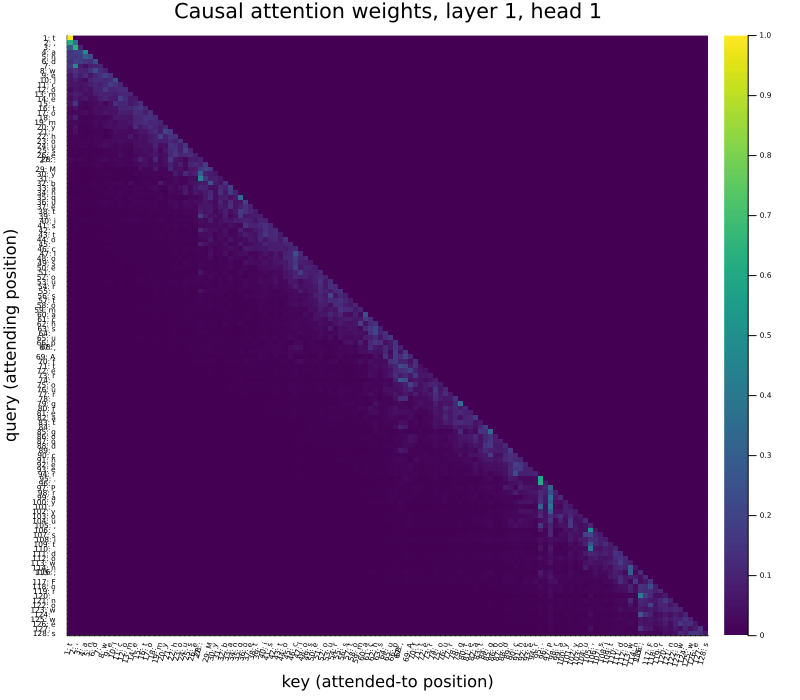

In [8]:
let
    # plot the attention weights for the selected head
    A = attn_w[:, :, ATTN_HEAD_INDEX, ATTN_SAMPLE_INDEX];
    T = size(A, 1);
    labels = [c == '\n' ? "\\n" : string(c) for c in input_chars];
    tick_labels = ["$(i): $(labels[i])" for i in 1:T];
    heatmap(1:T, 1:T, A;
            xlabel = "key (attended-to position)",
            ylabel = "query (attending position)",
            title  = "Causal attention weights, layer $(ATTN_BLOCK_INDEX), head $(ATTN_HEAD_INDEX)",
            color  = :viridis,
            size   = (800, 700),
            yflip  = true,
            xticks = (1:T, tick_labels),
            yticks = (1:T, tick_labels),
            xrotation = 75,
            xtickfont = font(5),
            ytickfont = font(5))
end

## Discussion
The plot above shows what the causal mask buys: every row of the heatmap has nonzero values only in the lower-left triangle. A few questions to think through:

* __What does each row of the heatmap mean?__ Row $i$ is the attention distribution used when computing the output at position $i$. Where does the model place most of its weight?
* __Why are upper-right entries exactly zero?__ The causal mask sets every score at $(i, j)$ with $j > i$ to $-10^{9}$ before softmax, and $\exp(-10^{9})$ rounds to zero.
* __What did greedy decoding produce, and why is it bad?__ Greedy decoding is deterministic, so once it enters a repeating pattern it cannot escape. Temperature and top-$k$ sampling break the loop by injecting randomness.
* __What has the model NOT learned?__ The samples reproduce line breaks, speech tags, and word-shaped sequences, but not spelling, grammar, or semantics. What would you change to push the model toward more coherent output?
* __How does parameter count scale with model dimension?__ The dominant term is $L\cdot 12 d^{2}$. If you double $d$ from $64$ to $128$, by what factor does the per-block parameter count increase? Verify by counting parameters of a $d=128$ model.

## Summary
This notebook trained a small decoder-only language model on Tiny Shakespeare and sampled from it with greedy, temperature, and top-$k$ decoding. The output is not readable English, and it was not supposed to be. What we wanted to see, and did see, is that the full transformer machinery from the lecture can be stood up end-to-end, trained with next-token cross-entropy, and made to produce text whose surface structure reflects the training corpus.

> __Key Takeaways:__
>
> * __A small decoder-only model is enough to see the lecture's claims in practice:__ With a modest parameter count and a short training run, the model produces output with the right surface structure (line breaks, character names, speech tags) even though no individual word is real English. That is the expected outcome for a character-level model at this scale, and it is the evidence that next-token training is doing its job.
> * __Greedy decoding fails as predicted:__ Picking the highest-logit token at every step drops the model into a repetition loop. Temperature and top-$k$ sampling fix this by injecting controlled randomness, which is why production systems never use pure greedy decoding.
> * __The causal attention heatmap visualizes the causal mask directly:__ A trained head's attention weights are strictly lower-triangular, with all upper-triangular entries equal to zero. This is the architectural constraint that makes autoregressive training parallelizable.

To push the same architecture toward readable output, scale is the lever:

* __Train longer on more data:__ Increase the parameter count, the corpus size, and the number of gradient steps; at some point the model has enough capacity and exposure to learn word-level regularities rather than just character-level ones.
* __Change the tokenizer:__ Replace character-level tokens with subword or word-level tokens so the model no longer has to relearn that common letter sequences form words.

The causal mask, decoder block, embedding tables, and cross-entropy loss are already the production components.
___